**Analysis Steps**:
- Import ES trading data and clean ready for merging
- Import S&P E-mini Futures data and clean ready for merging
- Merge ES trading data into Futures data for analysis of daily settlement/returns
- Perform analysis on trading strategy:
    - Mean returns and volatility
    - Correlation/Beta with futures data (determine alpha)
    - Maximum drawdown, hit rate, sharpe ratio, etc. 
    - Plots
- Put together initial summary of findings, ready for "new" strategy investigation.

**1. Import and clean ES Trading Data 2020-2025**:

Import Libraries:

In [16]:
# Import libraries
import pandas as pd 
import numpy as np 
import math 
import statistics 
import matplotlib.pyplot as plt 
import yfinance as yf

# Outputs
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
from reportlab.lib import colors

# Display Preferences
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

File import:

In [3]:
# Import and inspect ES_2020-2025.csv 
raw_df = pd.read_csv(r".\Signal_data\ES_2020-2025.csv", sep=";", engine="python") 

# Remove first row of NaN data
raw_df = raw_df.iloc[1:].reset_index(drop=True) 

# Remove the imported but empty last column 
raw_df = raw_df.iloc[:,:-1]

# Display current header 
raw_df.head() 

,Quarter,Model_Classification_ID,Entry_Date_ISO,ES_Entry_Price,Direction,Exit_Date_ISO,ES_Exit_Price
0,q3-20,q3-20_1,2020-08-10,"3347,00",-1.0,2020-08-11,"3350,25"
1,q3-20,q3-20_2,2020-08-11,"3350,25",1.0,2020-08-19,"3388,75"
2,q3-20,q3-20_3,2020-08-19,"3388,75",-1.0,2020-08-20,"3370,25"
3,q3-20,q3-20_4,2020-08-20,"3370,25",1.0,2020-08-28,"3488,00"
4,q4-20,q4-20_1,2020-09-25,"3243,50",1.0,2020-09-28,"3291,00"


Edit column values and tidy:

In [4]:
# Change column names
columns = ["Quarter", "Model_Classification_ID", "Entry_Date", "Entry_Price", "Signal", "Exit_Date", "Exit_Price"]
raw_df.columns = columns 

# Change prices to floats 
raw_df["Entry_Price"] = raw_df["Entry_Price"].str.replace(",", ".").astype(float) 
raw_df["Exit_Price"] = raw_df["Exit_Price"].str.replace(",", ".").astype(float)

# Change date strings to datetime 
raw_df["Entry_Date"] = pd.to_datetime(raw_df["Entry_Date"])
raw_df["Exit_Date"] = pd.to_datetime(raw_df["Exit_Date"])

# Refine Quarter tags
raw_df["Quarter"] = ("20" + raw_df.Quarter.str[-2:] + "Q" + raw_df.Quarter.str[1])

# Drop Unnecessary columns
raw_df = raw_df.drop(columns=["Model_Classification_ID"])

# Review data formatting
raw_df.info()

# Rename trade data
trade_df = raw_df.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Quarter      117 non-null    object        
 1   Entry_Date   117 non-null    datetime64[ns]
 2   Entry_Price  117 non-null    float64       
 3   Signal       117 non-null    float64       
 4   Exit_Date    117 non-null    datetime64[ns]
 5   Exit_Price   117 non-null    float64       
dtypes: datetime64[ns](2), float64(3), object(1)
memory usage: 5.6+ KB


Review final trade data:

In [5]:
# Review final trade data
trade_df.head()

,Quarter,Entry_Date,Entry_Price,Signal,Exit_Date,Exit_Price
0,2020Q3,2020-08-10,3347.00,-1.0,2020-08-11,3350.25
1,2020Q3,2020-08-11,3350.25,1.0,2020-08-19,3388.75
2,2020Q3,2020-08-19,3388.75,-1.0,2020-08-20,3370.25
3,2020Q3,2020-08-20,3370.25,1.0,2020-08-28,3488.00
4,2020Q4,2020-09-25,3243.50,1.0,2020-09-28,3291.00


**1b. Import and clean ES Trading Data 2025-2026**:

In [6]:
# Import data
SD_1_df = pd.read_csv(r".\Signal_data\Subset_data_cleaned.csv", index_col=0, parse_dates=True)

# Preview
SD_1_df 

,Quarter,Signal,Entry_Price
index,,,
2025-06-23,2025Q3,1,5964.00
2025-06-24,2025Q3,1,6078.00
2025-06-25,2025Q3,1,6144.75
2025-06-26,2025Q3,1,6144.75
2025-06-27,2025Q3,1,6197.50
...,...,...,...
2026-03-16,2026Q1,1,6608.50
2026-03-17,2026Q1,1,6700.00
2026-03-18,2026Q1,1,6722.50


In [7]:
# Import data
SD_2_df = pd.read_csv(r".\Signal_data\Q2_data_cleaned.csv", index_col=0, parse_dates=True)

# Preview
SD_2_df.head() 

,Quarter,Signal,Entry_Price
index,,,
2026-03-30,2020Q2,0,6380.00
2026-03-31,2020Q2,1,6385.25
2026-04-01,2020Q2,1,6562.00
2026-04-02,2020Q2,1,6618.50
2026-04-03,2020Q2,-1,6622.50


**2. Import and clean E-Mini Futures Data**

Market Data import:

In [8]:
# Comment out and pull from CSV 
ES_df = yf.download("ES=F", start=trade_df["Entry_Date"].iloc[0], end= (SD_2_df.index[-1] + pd.Timedelta(days=1)), auto_adjust=False) 
ES_df.columns = ES_df.columns.droplevel(1)
ES_df.reset_index().to_csv(r".\Market_data\ES_daily.csv", index=False)
print(ES_df)

[*********************100%***********************]  1 of 1 completed

Price       Adj Close    Close     High      Low     Open   Volume
Date                                                              
2020-08-10    3352.75  3352.75  3357.25  3329.00  3347.00  1201751
2020-08-11    3330.00  3330.00  3379.00  3319.50  3350.25  1733040
2020-08-12    3370.00  3370.00  3382.50  3326.25  3339.50  1408718
2020-08-13    3367.75  3367.75  3382.00  3357.50  3367.75  1205758
2020-08-14    3361.50  3361.50  3380.50  3350.00  3369.25  1084771
...               ...      ...      ...      ...      ...      ...
2026-06-09    7392.75  7392.75  7491.00  7247.25  7412.75  2505679
2026-06-10    7278.50  7278.50  7404.75  7256.00  7380.00  1851849
2026-06-11    7396.00  7396.00  7420.00  7232.25  7259.25  2295133
2026-06-12    7435.00  7435.00  7461.75  7366.50  7397.50  2295133
2026-06-15    7618.75  7618.75  7622.50  7542.00  7480.00   534581

[1472 rows x 6 columns]


Import market data from csv:

In [9]:
# Import data
ES_df = pd.read_csv(
    r".\Market_data\ES_daily.csv",
    index_col=0,
    parse_dates=True
)

**3. Merge Trading and Market Data for Analysis**:

In [10]:
# Create new Trading Strategy Dataframe
TS_df = ES_df.copy() 
TS_df.index = pd.to_datetime(TS_df.index)

# Add signal column
TS_df["Signal"] = 0 

# Add Quarter column
TS_df["Quarter"] = ""

# Fill trade signals from ES_2020-2025
for _, row in trade_df.iterrows():
    TS_df.loc[(TS_df.index >= row["Entry_Date"]) & (TS_df.index < row["Exit_Date"]), "Signal"] = row["Signal"]
    TS_df.loc[(TS_df.index >= row["Entry_Date"]) & (TS_df.index < row["Exit_Date"]), "Quarter"] = row["Quarter"]

# Fill trade signals from Subset data
common_idx = SD_1_df.index.intersection(TS_df.index)
TS_df.loc[common_idx, "Signal"] = SD_1_df.loc[common_idx, "Signal"]
TS_df.loc[common_idx, "Quarter"] = SD_1_df.loc[common_idx, "Quarter"]

# Fill trade signals from Q2 data
common_idx = SD_2_df.index.intersection(TS_df.index)
TS_df.loc[common_idx, "Signal"] = SD_2_df.loc[common_idx, "Signal"]
TS_df.loc[common_idx, "Quarter"] = SD_2_df.loc[common_idx, "Quarter"]

# Add Market Log Returns
TS_df["Log_Returns_Market"] = np.log(TS_df["Open"]/TS_df["Open"].shift(1))
TS_df["Log_Returns_Market"] = TS_df["Log_Returns_Market"].fillna(0)

# Add Strategy Log Returns
TS_df["Log_Returns_Strategy"] = TS_df["Signal"].shift(1) * TS_df["Log_Returns_Market"]
TS_df["Log_Returns_Strategy"] = TS_df["Log_Returns_Strategy"].fillna(0)

# Add Cum Returns 
TS_df["Cum_Market"] = np.exp(TS_df["Log_Returns_Market"].cumsum())
TS_df["Cum_Strategy"] = np.exp(TS_df["Log_Returns_Strategy"].cumsum())

# Running Equity Peak 
running_peak = TS_df["Cum_Strategy"].cummax() 

# Drawdown in pct 
TS_df["Drawdown"] = (TS_df["Cum_Strategy"] - running_peak) / running_peak 

# Maximum drawdown experience at each point 
TS_df["Max_Drawdown"] = TS_df["Drawdown"].cummin() 

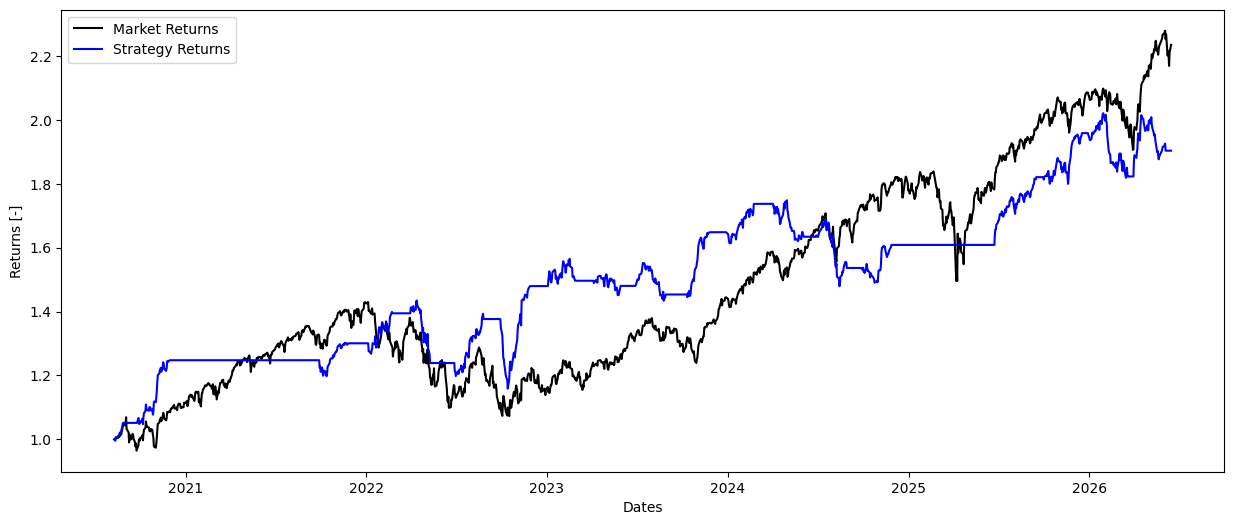

In [11]:
# Plot Results
plt.figure(figsize=(15,6))
plt.plot(TS_df.index, TS_df.Cum_Market, 'k-', label="Market Returns") 
plt.plot(TS_df.index, TS_df.Cum_Strategy, 'b-', label="Strategy Returns") 
plt.legend()
plt.xlabel("Dates") 
plt.ylabel("Returns [-]")
plt.show()

**4. Analysis of Trading Strategy**:

In [12]:
# Isolate active trading strategy data and corresponding market
strat_df = TS_df[(TS_df["Signal"] != 0)].copy()

# Review signal stats
Num_signals = len(strat_df)
print(f"No. of Historical Signal = {Num_signals}")
Num_hit = (strat_df["Log_Returns_Strategy"] > 0).astype(int).sum()
print(f"No. of hits: {Num_hit}")
Num_miss = Num_signals - Num_hit
print(f"No. of misses: {Num_miss}")
print(f"Hit Rate: {(Num_hit/Num_signals)*100:.2f}%")

# Assess Capital & Returns
Max_drawdown = strat_df["Max_Drawdown"].min() 
Return_mean = strat_df["Log_Returns_Strategy"].mean() 
Return_vol = strat_df["Log_Returns_Strategy"].std() 

print(f"Maximum Drawdown: {abs(Max_drawdown):,.2%}")
print(f"Mean Daily Return: {Return_mean:,.4}")
print(f"Std. Daily Return: {Return_vol:,.4}")

rf = 0.045 / 252 # risk-free rate
print(f"Risk-free rate: {rf:,.4}")

Sharpe = ((Return_mean - rf) / Return_vol) * math.sqrt(252)
print(f"Sharpe: {Sharpe:.3}")

# Annualised Figures
total_log_return = TS_df["Log_Returns_Strategy"].sum()
years = len(TS_df) / 252

annualized_return = np.exp(total_log_return / years) - 1
calmar = annualized_return / abs(Max_drawdown)

print(f"Annualized Return: {annualized_return:.2%}")
print(f"Calmar Ratio: {calmar:.3f}")


No. of Historical Signal = 782
No. of hits: 408
No. of misses: 374
Hit Rate: 52.17%
Maximum Drawdown: 19.21%
Mean Daily Return: 0.0008322
Std. Daily Return: 0.009619
Risk-free rate: 0.0001786
Sharpe: 1.08
Annualized Return: 11.65%
Calmar Ratio: 0.606


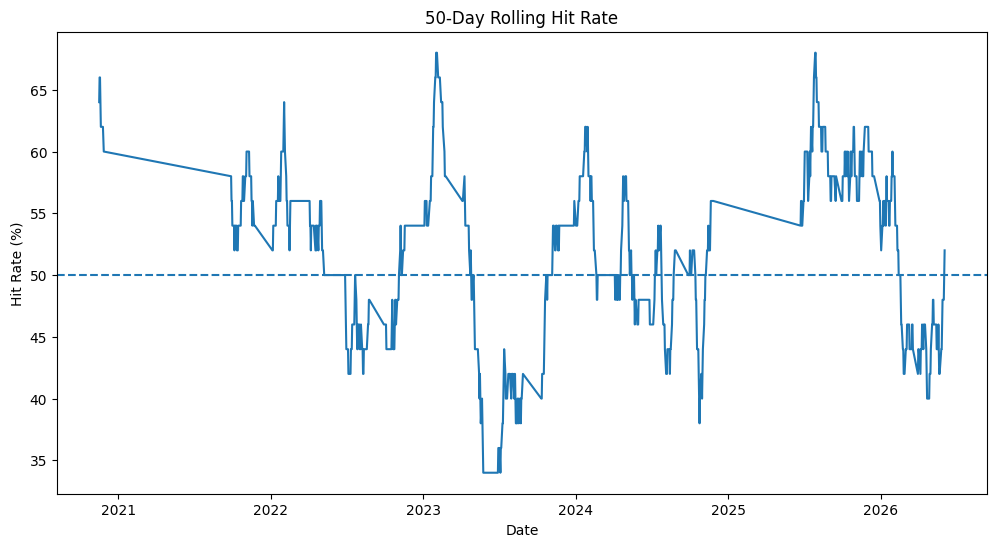

In [13]:
# Assess days with a signal/position
strat_df["Active"] = np.abs(strat_df["Signal"].shift(1)) > 0

# Add a hit column
strat_df["Hit"] = np.where(strat_df["Active"],(strat_df["Log_Returns_Strategy"] > 0).astype(float),np.nan)

# Add rolling hit column
window = 50
strat_df["Rolling_Hit_50"] = strat_df["Hit"].rolling(window).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(strat_df.index, strat_df["Rolling_Hit_50"] * 100)
plt.axhline(50, linestyle="--")
plt.ylabel("Hit Rate (%)")
plt.xlabel("Date")
plt.title(f"{window}-Day Rolling Hit Rate")
plt.show()

**5. Review Quarterly Performance**:

In [20]:
# Rearrange Quarter markers for contract period assessment
strat_df["Quarter"] = pd.PeriodIndex(strat_df["Quarter"], freq="Q")

# Contract statistics/summary
quarter_stats = strat_df.groupby("Quarter").agg(
    Hit_Rate=("Hit", "mean"),
    Avg_Return=("Log_Returns_Strategy", "mean"),
    Total_Return=("Log_Returns_Strategy", "sum"),
    Volatility=("Log_Returns_Strategy", "std"),
    Trades=("Signal", lambda x: (x != 0).sum())
)
quarter_stats["Sharpe"] = (
    (quarter_stats["Avg_Return"] - rf) / quarter_stats["Volatility"]
) * np.sqrt(252)

# Contract duration market stats
market_stats = strat_df.groupby("Quarter").agg(
    Avg_Return=("Log_Returns_Market", "mean"),
    Total_Return=("Log_Returns_Market", "sum"),
    Volatility=("Log_Returns_Market", "std"),
)
market_stats["Sharpe"] = (
    (market_stats["Avg_Return"] - rf) / market_stats["Volatility"]
) * np.sqrt(252)

# Display results
quarter_stats


,Hit_Rate,Avg_Return,Total_Return,Volatility,Trades,Sharpe
Quarter,,,,,,
2020Q2,0.533333,0.001221,0.054965,0.008751,45,1.891751
2020Q3,0.769231,0.003417,0.047831,0.003969,14,12.950360
2020Q4,0.555556,0.003718,0.167309,0.010794,45,5.205263
2021Q4,0.571429,0.000918,0.038560,0.006882,42,1.705906
2022Q1,0.545455,0.002206,0.072795,0.011947,33,2.693852
2022Q2,0.428571,-0.004248,-0.118941,0.015758,28,-4.459229
2022Q3,0.523810,0.002790,0.117160,0.010660,42,3.888050
2022Q4,0.512195,0.001651,0.067673,0.017796,41,1.313065
2023Q1,0.567568,0.000567,0.020964,0.009710,37,0.634351


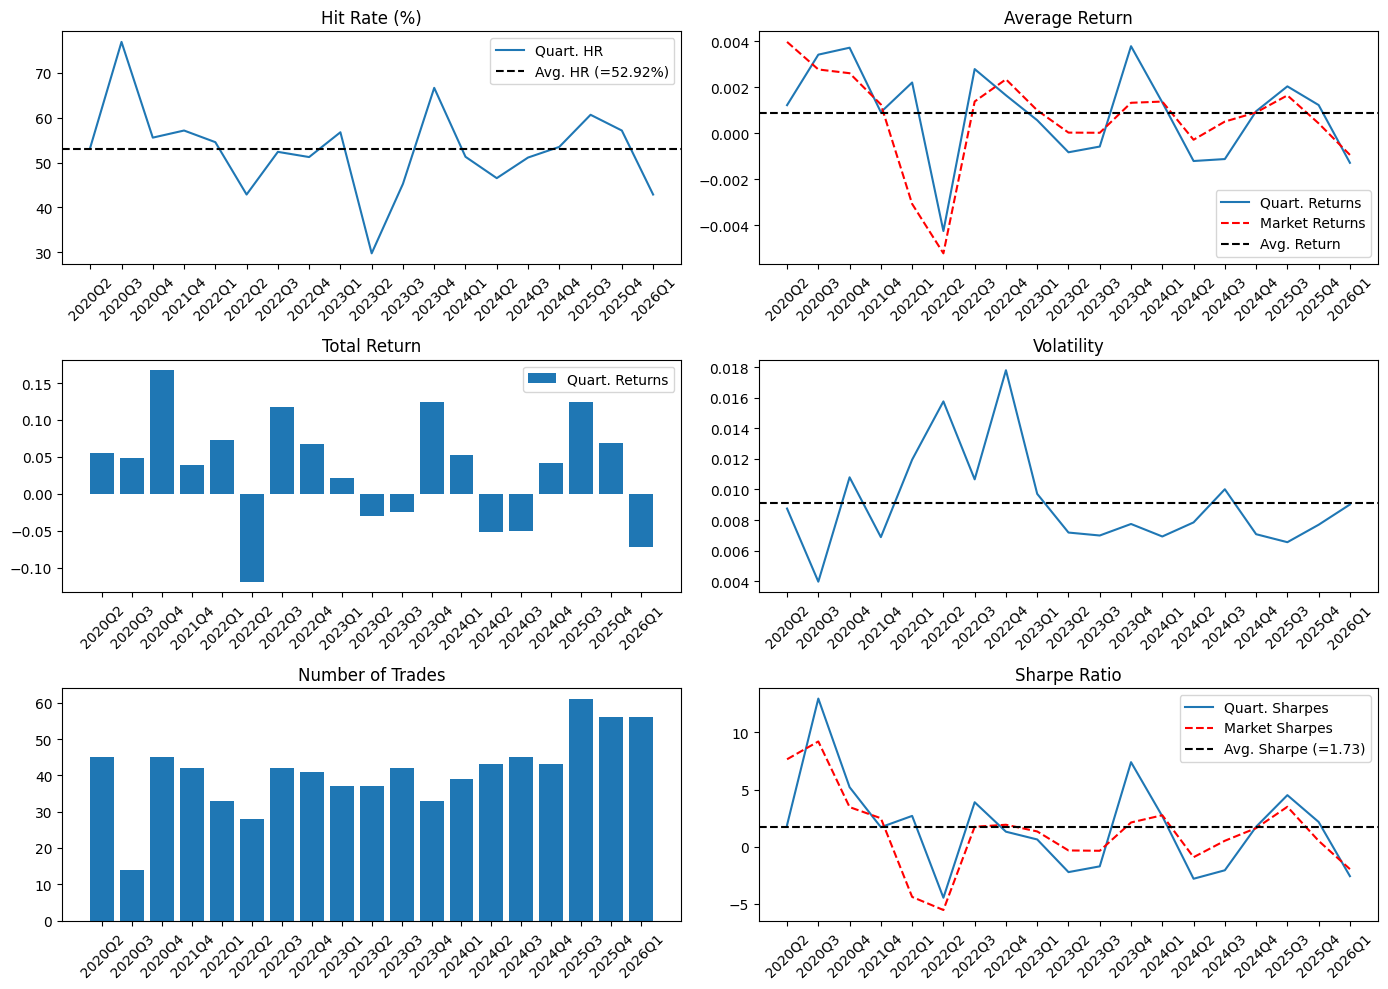

In [29]:
### Plot results ###

# Figure details 
fig, axes = plt.subplots(3, 2, figsize=(14,10)) 
axes = axes.flatten() 

# --- Hit Rate --- 
axes[0].plot(quarter_stats.index.astype(str), quarter_stats["Hit_Rate"] * 100, label="Quart. HR") 
avg_HR = quarter_stats["Hit_Rate"].mean() * 100
axes[0].axhline(avg_HR, linestyle="--", color="black", label=f"Avg. HR (={avg_HR:.2f}%)") 
axes[0].set_title("Hit Rate (%)") 
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45) 

# --- Avg Return --- 
axes[1].plot(quarter_stats.index.astype(str), quarter_stats["Avg_Return"], label="Quart. Returns") 
axes[1].plot(market_stats.index.astype(str), market_stats["Avg_Return"], linestyle="--", color="red", label="Market Returns") 
axes[1].axhline(quarter_stats["Avg_Return"].mean(), linestyle="--", color="black", label="Avg. Return")
axes[1].set_title("Average Return") 
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

# --- Total Return ---
axes[2].bar(quarter_stats.index.astype(str), quarter_stats["Total_Return"], label="Quart. Returns")
#axes[2].bar(market_stats.index.astype(str), market_stats["Total_Return"], linestyle="--", color="red")
axes[2].set_title("Total Return")
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

# --- Volatility ---
axes[3].plot(quarter_stats.index.astype(str), quarter_stats["Volatility"], label="Quart. Vol.")
#axes[3].plot(market_stats.index.astype(str), market_stats["Volatility"], linestyle="--", color="red", label="Market Vol.")
avg_volatility = quarter_stats["Volatility"].mean()
axes[3].axhline(avg_volatility, linestyle="--", color="black", label=f"Avg. Vol. (={avg_volatility:.3f})")
axes[3].set_title("Volatility")
#axes[3].legend()
axes[3].tick_params(axis='x', rotation=45)

# --- Trades ---
axes[4].bar(quarter_stats.index.astype(str), quarter_stats["Trades"])
axes[4].set_title("Number of Trades")
#axes[4].legend()
axes[4].tick_params(axis='x', rotation=45)

# --- Sharpe ---
axes[5].plot(quarter_stats.index.astype(str), quarter_stats["Sharpe"], label="Quart. Sharpes")
axes[5].plot(market_stats.index.astype(str), market_stats["Sharpe"], linestyle="--", color="red", label="Market Sharpes")
avg_sharpe = quarter_stats["Sharpe"].mean()
axes[5].axhline(quarter_stats["Sharpe"].mean(), linestyle="--", color="black", label=f"Avg. Sharpe (={avg_sharpe:.2f})")
axes[5].set_title("Sharpe Ratio")
axes[5].legend()
axes[5].tick_params(axis='x', rotation=45)

# Save figure
plt.tight_layout()
plt.savefig(r".\Figures\quarter_stats_plot.pdf", bbox_inches="tight")
plt.show()

**6. Report Findings:**

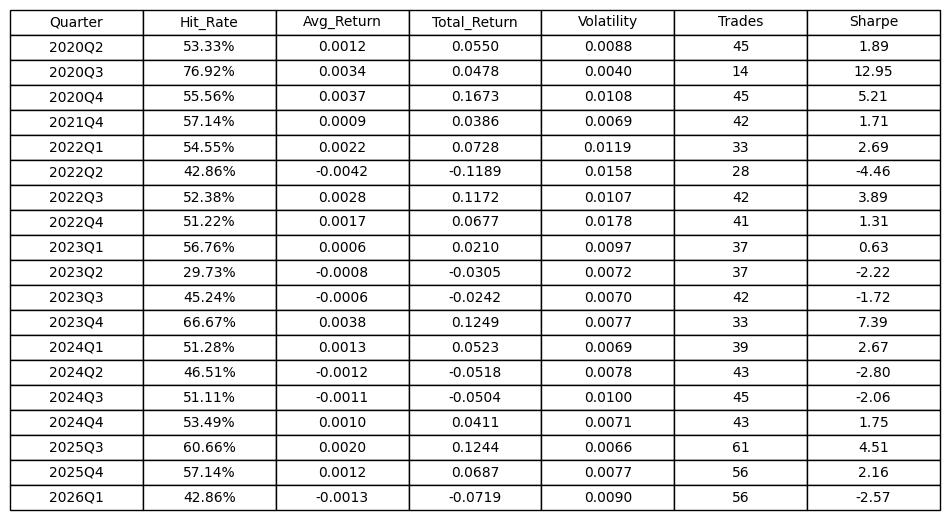

In [27]:
# Create output table
table_df = quarter_stats.reset_index().copy()

# Format output numbers
table_df["Hit_Rate"] = table_df["Hit_Rate"].map(lambda x: f"{x:.2%}")
table_df["Avg_Return"] = table_df["Avg_Return"].map(lambda x: f"{x:.4f}")
table_df["Total_Return"] = table_df["Total_Return"].map(lambda x: f"{x:.4f}")
table_df["Volatility"] = table_df["Volatility"].map(lambda x: f"{x:.4f}")
table_df["Sharpe"] = table_df["Sharpe"].map(lambda x: f"{x:.2f}")

# Create output figure
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

# Figure contents/format
tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

# Save figure
plt.savefig(r".\Figures\quarter_stats.pdf", bbox_inches="tight")
plt.show()